In [1]:
import numpy as np
import datetime
import pandas as pd
import random

In [2]:
#X=pd.read_csv('nifty.csv')
#len(X)

In [3]:
def data1():
    X=pd.read_csv('tempcnnlstmcluster.csv')
    X = X.iloc[60:]  # Keep rows from index 19 onwards (0-based index)
    # Ensure 'Open' and 'Close' are treated as numeric
    X['cashopen']=0
    X['cash']=0
    # Ensure columns have float dtype before assignment
    X['cashopen'] = X['cashopen'].astype(float)
    X['cash'] = X['cash'].astype(float)
    X['action']=""
    X['diff']=""
    X['quantity']=""
    return X
    

In [4]:
X=data1()

In [5]:
print(len(X))

2785


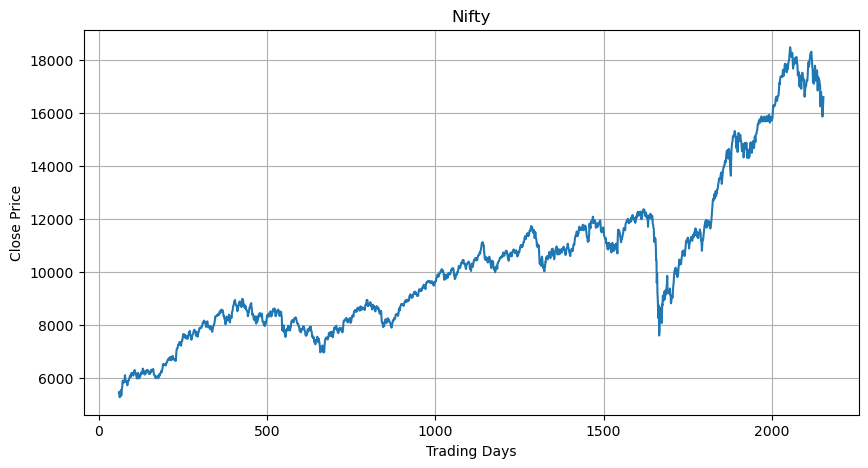

In [6]:
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure()
ax=X.loc[60:2153,'Close'].plot(grid="True",figsize=(10,5), title='Nifty')
ax.set_xlabel("Trading Days")
ax.set_ylabel("Close Price")
plt.show()
fig.savefig('nifty_close.png')

In [7]:
X.head()

,Unnamed: 0.1,Unnamed: 0,index,Close,High,Low,Open,Volume,date,weekday,...,cnnstate,p_co,state2d,state1d,Cluster,cashopen,cash,action,diff,quantity
60,60,60,160,5471.750000,5478.799805,5377.799805,5428.750000,251500,23-08-2013,1.00,...,0.0,0.505321,3.0,5.0,4.0,0.0,0.0,,,
61,61,61,161,5476.500000,5528.700195,5454.450195,5499.399902,242000,26-08-2013,0.00,...,0.0,-0.912992,0.0,2.0,3.0,0.0,0.0,,,
62,62,62,162,5287.450195,5427.399902,5274.250000,5426.500000,306000,27-08-2013,0.25,...,2.0,-1.021286,2.0,2.0,3.0,0.0,0.0,,,
63,63,63,163,5285.000000,5317.700195,5118.850098,5233.450195,336000,28-08-2013,0.50,...,2.0,0.596026,5.0,5.0,2.0,0.0,0.0,,,
64,64,64,164,5409.049805,5428.899902,5303.000000,5316.500000,326500,29-08-2013,0.75,...,2.0,-0.029573,2.0,2.0,3.0,0.0,0.0,,,


In [8]:
X['Cluster'].value_counts()

Cluster
2.0    656
3.0    472
0.0    435
4.0    396
1.0    296
6.0    269
5.0    149
7.0    112
Name: count, dtype: int64

In [9]:
#X.head()

In [10]:
def getState(t):
    t = int(t)
    return(X['Cluster'][t])  

In [11]:
class Agent:
    def __init__(self):
        self.epsilon = 1.0
        self.gamma = 0.618
        self.epsilon_decay = 0.999
        self.epsilon_min = 0.01
        self.Q = np.matrix(np.zeros([8,3]))
        self.learning_rate=0.03
        
    def getAction(self,state):
        state = int(state)
        a=[1,0,2]
        if np.random.rand() <= self.epsilon:
            return random.choice(a)
        return np.argmax(self.Q[state,])  
    
    # Update Q(s,a):= Q(s,a) + lr [R(s,a) + gamma * max Q(s',a') - Q(s,a)]
    def update(self,state,action,reward,next_state,next_action):
        state = int(state)
        action = int(action)
        next_state = int(next_state)
        self.Q[state,action]= self.Q[state,action] + self.learning_rate * (reward + self.gamma * np.max(self.Q[next_state, :])
                                                                - self.Q[state,action])

        

In [13]:
episode_count=100
agent=Agent()
agent.Q
m1=0
m2=0
for e in range(1,episode_count+1):
    X=data1()
    
    data_length_start=61
    data_length=2107
    state = getState(data_length_start-1)
    action = agent.getAction(state)
    
  
    capital=X.loc[data_length_start,'Open']*10
    margin=X.loc[data_length_start,'Open']*10
    #X.loc[2,'cashopen']=margin 
    X.loc[2, 'cashopen'] = float(margin)
    brok_rate=0.0000
    #brok_rate=0.0
    
    print("Episod {}/{}".format(e,episode_count))
    count=0
    for t in range(data_length_start,data_length):
                
        reward=0                        
         
        if action == 1:
            X.loc[t,'cashopen']=float(margin)
            quantity=margin//X.loc[t,'Open']
            X.loc[t,'quantity']=quantity
            margin=margin%X.loc[t,'Open']
            tbrokerage=(X.loc[t,'Open']+X.loc[t,'Close'])*brok_rate
            tprofit=(X.loc[t,'Close']-X.loc[t,'Open']-tbrokerage)*quantity
            margin=margin+tprofit+X.loc[t,'Open']*quantity
            X.loc[t,'cash']=float(margin)         
            
            #print('Long: open price @',X.loc[t,'Open'],'Close price @',X.loc[t,'Close'], 'profit=',tprofit)
            X.loc[t,'action']="long"
            X.loc[t,'diff']=(X.loc[t,'Close']-X.loc[t,'Open']-tbrokerage)*quantity
            count=count+1
            reward= max((np.log(X.loc[t,'Close'])-np.log(X.loc[t,'Open']+tbrokerage)),0)
            
       
        elif action == 2:
            X.loc[t,'cashopen']=float(margin) 
            quantity=margin//X.loc[t,'Open']
            X.loc[t,'quantity']=(-quantity)
            margin=margin%X.loc[t,'Open']
            tbrokerage=(X.loc[t,'Open']+X.loc[t,'Close'])*brok_rate
            tprofit=(X.loc[t,'Open']-X.loc[t,'Close']-tbrokerage)*quantity
            #print('in Short')
            margin=margin+tprofit+X.loc[t,'Open']*quantity
            X.loc[t,'cash']=float(margin)         
            last_action='Short'
            #print('Short: Close price @',X.loc[t,'Close'],'Open price @',X.loc[t,'Open'], 'profit=',tprofit)
            X.loc[t,'action']="short"
            X.loc[t,'diff']=(X.loc[t,'Open']-X.loc[t,'Close']-tbrokerage)*quantity
            count=count+1
            reward= max((np.log(X.loc[t,'Open'])-np.log(X.loc[t,'Close']+tbrokerage)),0)
           
        else:
            X.loc[t,'cash']=margin
            X.loc[t,'action']="Hold"
            X.loc[t,'diff']=0
            reward=0                                  
              
        next_state=int(getState(t))
        next_action=agent.getAction(next_state)
        agent.update(state,action,reward,next_state,next_action)
        state=next_state
        action=next_action
        
        if t==data_length-1:
                print("\n***********************\n",t)
                print("Profit is ",(margin-capital))
                print("Initial Capital is ",capital)    
                print("Current Capital is ",margin)
                roi=((margin-capital)/capital)*100
                print("%ROI is ",roi)
                bnh=((X.loc[t,'Close']-X.loc[data_length_start,'Open'])/X.loc[data_length_start,'Open'])*100
                print("% Buy and Hold=",bnh)
                print("count",count)
                print("qtable",agent.Q)
                print("epsilon",agent.epsilon)
                print("--------------------------------")
                       
        if (agent.epsilon > agent.epsilon_min) and e>1:
                       agent.epsilon *= agent.epsilon_decay
                       
    
    m3=roi
    if m3>m2:
        m1=e
        m2=m3
    #To save model  
    if e%20==0:
        np.save('rl/Qtable'+ str(e)+str('.npy'), agent.Q)
        np.save('rl/epsilon'+ str(e)+str('.npy'), agent.epsilon)
        np.save('rl/gamma'+ str(e)+str('.npy'), agent.gamma)
        np.save('rl/learning_rate'+ str(e)+str('.npy'), agent.learning_rate)
        X.to_csv('csv1/AfterTrain'+str(e)+str('.csv'))
print("e={},roi={}".format(m1,m2))

Episod 1/100

***********************
 2106
Profit is  -6896.394579000043
Initial Capital is  54993.99902
Current Capital is  48097.60444099996
%ROI is  -12.540267487170716
% Buy and Hold= 215.56262663656716
count 1356
qtable [[0.00477402 0.00434383 0.01341147]
 [0.00345905 0.00386422 0.01051028]
 [0.00521555 0.01142604 0.00571917]
 [0.00526183 0.00950005 0.00771111]
 [0.00502236 0.00388688 0.01115753]
 [0.00276675 0.00388697 0.00263061]
 [0.00311661 0.00836855 0.00332716]
 [0.00150325 0.00244206 0.00190581]]
epsilon 1.0
--------------------------------
Episod 2/100

***********************
 2106
Profit is  22527068.35009002
Initial Capital is  54993.99902
Current Capital is  22582062.34911002
%ROI is  40962.77548737174
% Buy and Hold= 215.56262663656716
count 1747
qtable [[0.00717968 0.00670827 0.01751181]
 [0.00585515 0.00588104 0.01767393]
 [0.00743993 0.013527   0.00736086]
 [0.00694834 0.01228407 0.00977754]
 [0.00693811 0.00657181 0.01582328]
 [0.0041332  0.00937259 0.00388189]
 

In [14]:
agent.Q

matrix([[0.00968799, 0.00953941, 0.0191997 ],
        [0.0089255 , 0.00889487, 0.01850448],
        [0.00806582, 0.01401617, 0.00877555],
        [0.00824249, 0.00901795, 0.01212451],
        [0.00792632, 0.00791481, 0.01665829],
        [0.00721319, 0.01084831, 0.00717389],
        [0.00893198, 0.01551208, 0.00913841],
        [0.0052925 , 0.01781533, 0.005533  ]])

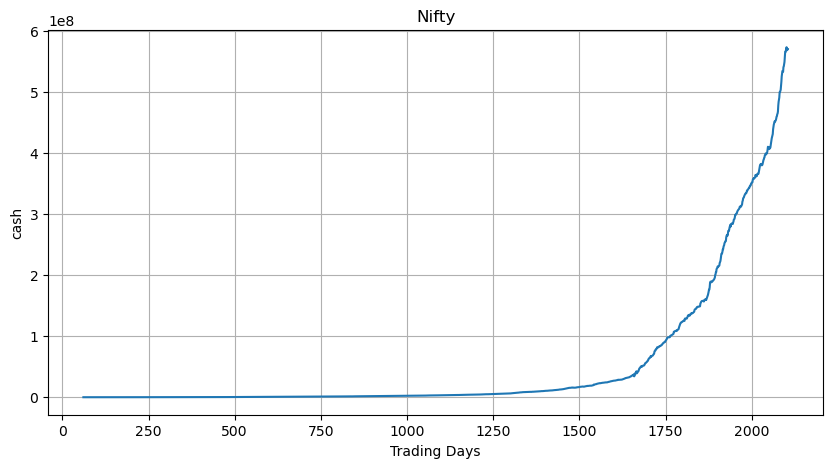

In [15]:
%matplotlib inline
fig = plt.figure()
ax=X.loc[data_length_start:data_length-2,'cash'].plot(grid="True",figsize=(10,5), title='Nifty')
ax.set_xlabel("Trading Days")
ax.set_ylabel("cash")
plt.show()